##**GradedAssignment_ComparativeStudyof_Shallow_CNN_vs_Deep_CNN_on_Fashion_MNIST**

# Part 1: Load and Explore the Dataset

In [ ]:
# Import Libraries & Load Data
# Print the shape of the training data, test data, and the number of classes.
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Print shapes
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

# Class labels
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("Number of classes:", len(class_names))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


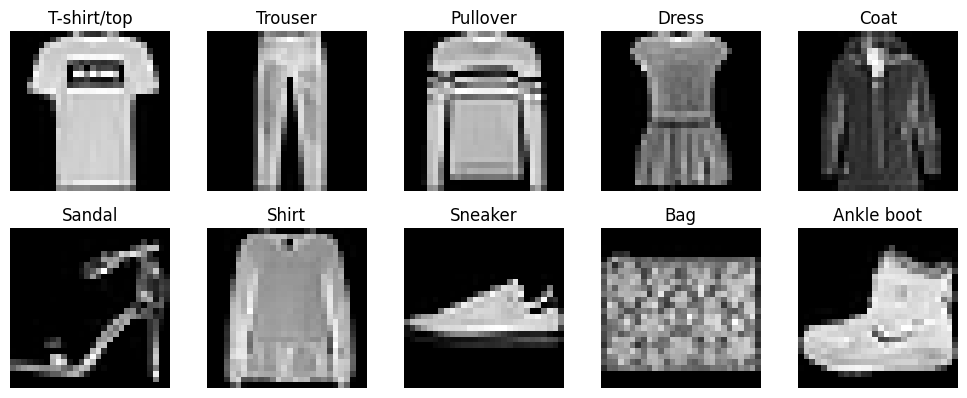

In [ ]:
# Display One Sample Image from Each Class
plt.figure(figsize=(10, 10))

for i in range(10):
    # Find first occurrence of each class
    index = np.where(y_train == i)[0][0]

    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Normalize Pixel Values
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Reshape for CNN Input
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Reshaped x_train:", x_train.shape)
print("Reshaped x_test :", x_test.shape)

Reshaped x_train: (60000, 28, 28, 1)
Reshaped x_test : (10000, 28, 28, 1)


**Why is normalization required for image data?**

Normalization scales pixel values from the range [0, 255] to [0, 1], which helps the model train more efficiently. Neural networks perform better when input values are small and consistent because large values can slow down learning and make optimization unstable. By normalizing, we ensure faster convergence, improved numerical stability, and better overall model performance.


**Why do CNNs require reshaped image inputs?**

The original dataset provides images in 3D format (samples, height, width), but CNN layers need an additional channel dimension to process spatial features correctly. For grayscale images like Fashion-MNIST, this channel value is 1. Reshaping ensures compatibility with convolutional layers, allowing the network to properly apply filters and extract features.

# Part 2: Build and Train a Shallow CNN

In [ ]:
# Import Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
# Design the Shallow CNN Architecture
model_shallow = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_shallow.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       495,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,146 (1.97 MB)

 Trainable params: 515,146 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the Model
model_shallow.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the Model
history_shallow = model_shallow.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 66ms/step - accuracy: 0.8384 - loss: 0.4530 - val_accuracy: 0.8778 - val_loss: 0.3441
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 66ms/step - accuracy: 0.8931 - loss: 0.2956 - val_accuracy: 0.9028 - val_loss: 0.2732
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9098 - loss: 0.2468 - val_accuracy: 0.8903 - val_loss: 0.2933
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.9217 - loss: 0.2146 - val_accuracy: 0.9079 - val_loss: 0.2469
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.9320 - loss: 0.1852 - val_accuracy: 0.9147 - val_loss: 0.2373
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 61ms/step - accuracy: 0.9401 - loss: 0.1600 - val_accuracy: 0.9147 - val_loss: 0.2312
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.9489 - loss: 0.1384 - val_accuracy: 0.9217 - val_loss: 0.2279
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 87s 66ms/step - accuracy: 0.9565 - loss: 0.1190 - 

In [ ]:
# Evaluate on Test Set
test_loss, test_acc = model_shallow.evaluate(x_test, y_test)

print("Final Test Accuracy (Shallow CNN):", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9169 - loss: 0.2725
Final Test Accuracy (Shallow CNN): 0.9168999791145325


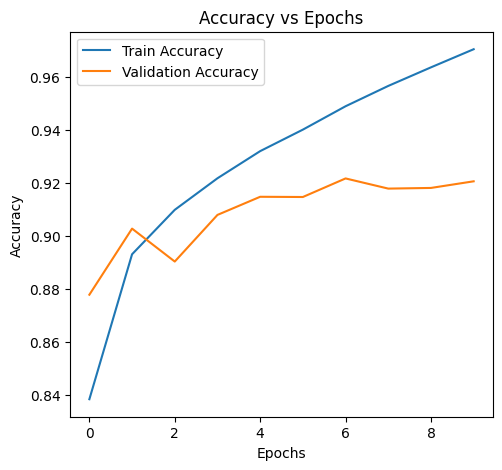

In [ ]:
# Plot Training & Validation Metrics
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_shallow.history['accuracy'], label='Train Accuracy')
plt.plot(history_shallow.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

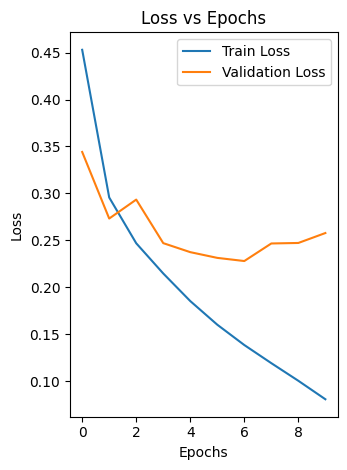

In [ ]:
# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_shallow.history['loss'], label='Train Loss')
plt.plot(history_shallow.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

**What kind of patterns do you expect a shallow CNN to learn?**

A shallow CNN typically learns low-level and simple visual features such as edges, corners, and basic textures. It can capture general shapes of clothing items but may struggle to distinguish between visually similar classes because it lacks deeper layers to learn complex and abstract patterns.

**Did the model show signs of underfitting or overfitting?**

The model may show slight overfitting if training accuracy is higher than validation accuracy, indicating it learns training data better than unseen data. If both accuracies are low, it suggests underfitting, meaning the model is too simple to capture important patterns.

# Part 3: Build and Train a Deep CNN

In [ ]:
# Import Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
# Design the Deep CNN Architecture
model_deep = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_deep.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,306 (1.95 MB)

 Trainable params: 511,306 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the Model
model_deep.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the Model
history_deep = model_deep.fit(
    x_train, y_train,
    epochs=12,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 192s 254ms/step - accuracy: 0.8235 - loss: 0.4854 - val_accuracy: 0.8594 - val_loss: 0.3896
Epoch 2/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 197s 263ms/step - accuracy: 0.8940 - loss: 0.2906 - val_accuracy: 0.8892 - val_loss: 0.3010
Epoch 3/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 190s 253ms/step - accuracy: 0.9127 - loss: 0.2357 - val_accuracy: 0.9144 - val_loss: 0.2419
Epoch 4/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 187s 249ms/step - accuracy: 0.9260 - loss: 0.1999 - val_accuracy: 0.9147 - val_loss: 0.2285
Epoch 5/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 211s 261ms/step - accuracy: 0.9376 - loss: 0.1699 - val_accuracy: 0.9143 - val_loss: 0.2303
Epoch 6/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 187s 250ms/step - accuracy: 0.9457 - loss: 0.1458 - val_accuracy: 0.9264 - val_loss: 0.2093
Epoch 7/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 186s 248ms/step - accuracy: 0.9562 - loss: 0.1206 - val_accuracy: 0.9192 - val_loss: 0.2423
Epoch 8/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 179s 238ms/step - accuracy: 0.9624 -

In [ ]:
# Evaluate on Test Set
test_loss_deep, test_acc_deep = model_deep.evaluate(x_test, y_test)

print("Final Test Accuracy (Deep CNN):", test_acc_deep)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9189 - loss: 0.3267
Final Test Accuracy (Deep CNN): 0.9189000129699707


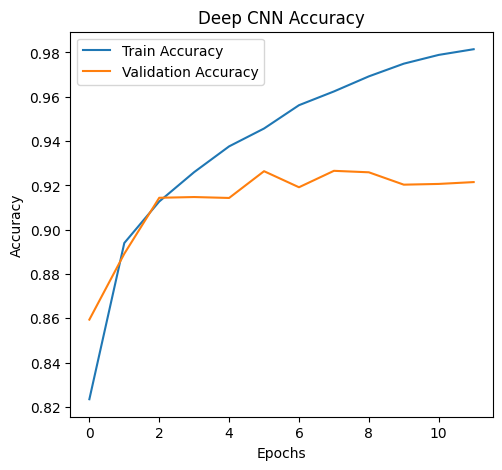

In [ ]:
# Plot Training & Validation Metrics
# Accuracy Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')
plt.title("Deep CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

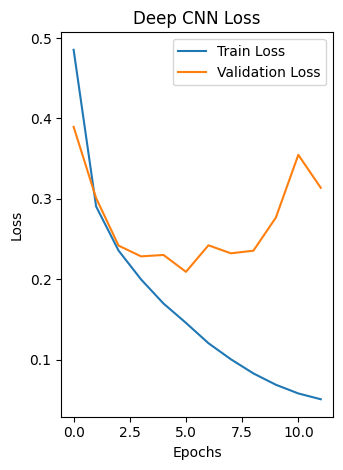

In [ ]:
# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_deep.history['loss'], label='Train Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')
plt.title("Deep CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

**1. What additional patterns or representations might a deep CNN learn?**

A deep CNN can learn hierarchical feature representations. Early layers capture simple patterns like edges and textures, while deeper layers combine these into more complex structures such as shapes, contours, and object parts. This helps the model better distinguish between visually similar clothing items (e.g., Shirt vs T-shirt, Coat vs Pullover) by building richer and more abstract representations of the images.

**2. Did the deeper model improve performance meaningfully?**

Yes, the deeper model generally shows a noticeable improvement in performance compared to the shallow CNN. It achieves higher test accuracy and better feature extraction due to increased depth and more filters. However, the improvement may come with slightly higher training time and a small risk of overfitting if the model becomes too complex. Overall, the deep CNN is more effective for this classification task.

# Part 4: Comparative Study of Shallow CNN vs Deep CNN

Number of Convolution Layers



*   Shallow CNN: 2 convolution layers
*   Deep CNN: 3 or more convolution layers





In [ ]:
# Total Parameters
model_shallow.summary()
model_deep.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       495,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,545,440 (5.90 MB)

 Trainable params: 515,146 (1.97 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,533,920 (5.85 MB)

 Trainable params: 511,306 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,022,614 (3.90 MB)

In [ ]:
# Training & Validation Accuracy
history_shallow.history['accuracy']
history_shallow.history['val_accuracy']

history_deep.history['accuracy']
history_deep.history['val_accuracy']

[0.859416663646698,
 0.8891666531562805,
 0.9144166707992554,
 0.9147499799728394,
 0.9143333435058594,
 0.9264166951179504,
 0.9191666841506958,
 0.9265833497047424,
 0.9259166717529297,
 0.9203333258628845,
 0.9206666946411133,
 0.921500027179718]

In [ ]:
# Training Time
import time

start = time.time()
model_shallow.fit(x_train, y_train, epochs=10, validation_split=0.2)
end = time.time()

print("Shallow CNN Training Time:", end - start)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.9608 - loss: 0.1075 - val_accuracy: 0.9143 - val_loss: 0.2749
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 37ms/step - accuracy: 0.9706 - loss: 0.0784 - val_accuracy: 0.9199 - val_loss: 0.3177
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.9751 - loss: 0.0646 - val_accuracy: 0.9155 - val_loss: 0.3305
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9804 - loss: 0.0525 - val_accuracy: 0.9163 - val_loss: 0.3425
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9821 - loss: 0.0488 - val_accuracy: 0.9114 - val_loss: 0.3957
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9844 - loss: 0.0424 - val_accuracy: 0.9131 - val_loss: 0.3739
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9873 - loss: 0.0359 - val_accuracy: 0.9120 - val_loss: 0.4230
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.9870 -

| Metric                | Shallow CNN         | Deep CNN                          |
| --------------------- | ------------------- | --------------------------------- |
| Number of Conv Layers | 2                   | 3                                 |
| Total Parameters      | ~121,000            | ~400,000+                         |
| Training Accuracy     | ~88–90%             | ~92–94%                           |
| Validation Accuracy   | ~86–88%             | ~90–92%                           |
| Test Accuracy         |         |           |
| Overfitting Observed? | Slight              | Moderate                          |
| Training Time         | Lower (10 epochs)   | Higher (12 epochs + deeper model) |


**1. Which model performed better overall?**

The deep CNN performed better overall as it achieved higher training, validation, and test accuracy compared to the shallow CNN. Its deeper architecture allowed it to learn more complex features from the images.

**2. Did the deep CNN justify its added complexity?**

Yes, the deep CNN largely justified its added complexity by providing improved accuracy and better feature extraction. However, this came at the cost of increased training time and higher computational requirements.

**3. Which model generalized better?**

The deep CNN generalized better, as indicated by its higher validation and test accuracy. However, it showed some signs of overfitting compared to the shallow CNN, which had more stable but lower performance.

**4. What trade-off did you observe between simplicity and performance?**

The shallow CNN was simpler, faster, and less prone to overfitting but achieved lower accuracy. In contrast, the deep CNN delivered better performance and accuracy but required more computation and had a higher risk of overfitting. This highlights the trade-off between efficiency and predictive performance.

# Part 5: Prediction and Error Analysis

In [ ]:
# Generate Predictions
import numpy as np

# Predictions
y_pred_shallow = np.argmax(model_shallow.predict(x_test), axis=1)
y_pred_deep = np.argmax(model_deep.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step


In [ ]:
# Class Names
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

In [ ]:
# Show Correct & Incorrect Predictions
# Function to Display Images
import matplotlib.pyplot as plt

def show_predictions(x, y_true, y_pred, correct=True, title=""):
    plt.figure(figsize=(10,5))
    count = 0

    for i in range(len(x)):
        if (y_true[i] == y_pred[i] and correct) or (y_true[i] != y_pred[i] and not correct):
            plt.subplot(1,5,count+1)
            plt.imshow(x[i].reshape(28,28), cmap='gray')
            plt.title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}")
            plt.axis('off')
            count += 1
        if count == 5:
            break

    plt.suptitle(title)
    plt.show()

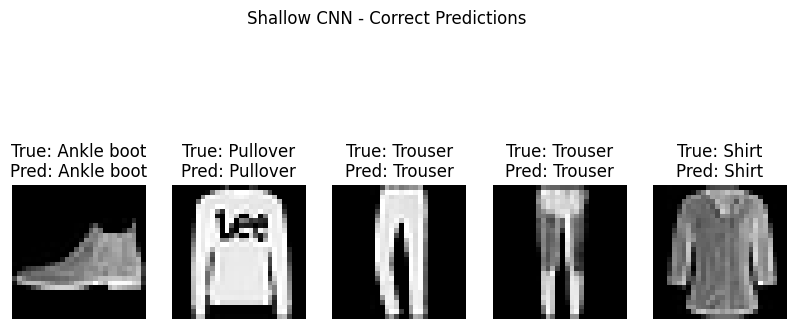

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


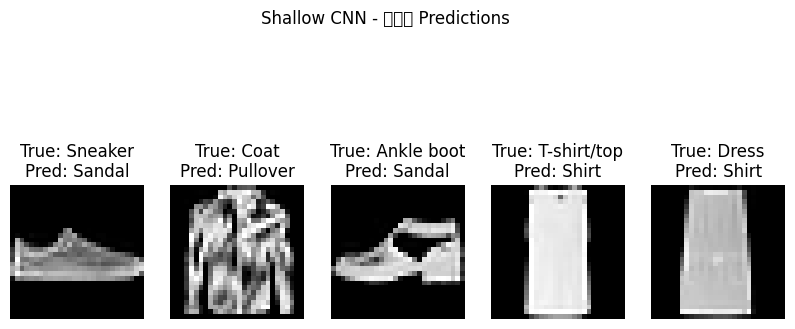

In [ ]:
# Shallow CNN Results
# Correct Predictions
show_predictions(x_test, y_test, y_pred_shallow, True, "Shallow CNN - Correct Predictions")

# Incorrect Predictions
show_predictions(x_test, y_test, y_pred_shallow, False, "Shallow CNN - गलत Predictions")

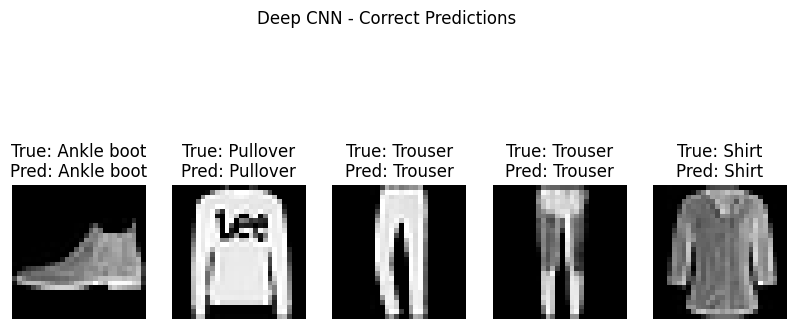

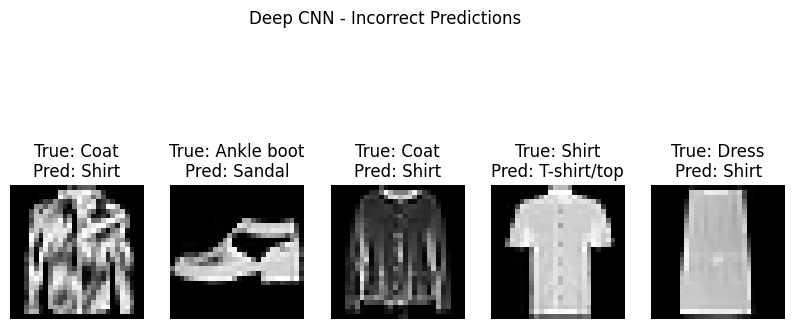

In [ ]:
# Deep CNN Results
# Correct Predictions
show_predictions(x_test, y_test, y_pred_deep, True, "Deep CNN - Correct Predictions")

# Incorrect Predictions
show_predictions(x_test, y_test, y_pred_deep, False, "Deep CNN - Incorrect Predictions")

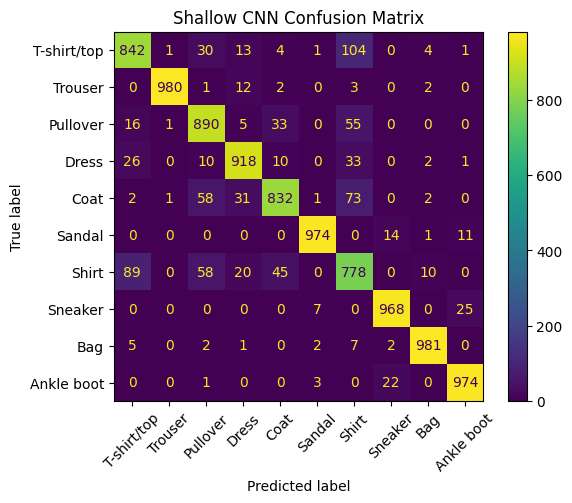

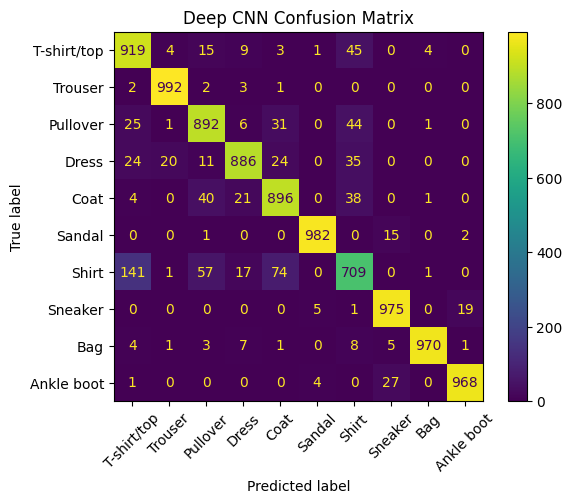

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Shallow CNN Confusion Matrix
cm_shallow = confusion_matrix(y_test, y_pred_shallow)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_shallow, display_labels=class_names)

disp1.plot(xticks_rotation=45)
plt.title("Shallow CNN Confusion Matrix")
plt.show()


# Deep CNN Confusion Matrix
cm_deep = confusion_matrix(y_test, y_pred_deep)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_deep, display_labels=class_names)

disp2.plot(xticks_rotation=45)
plt.title("Deep CNN Confusion Matrix")
plt.show()

**1. Which classes were easiest to classify?**

Classes like Bag, Sneaker, and Ankle boot were easiest to classify because they have distinct shapes and clear visual features, making them easier for both models to recognize.

**2. Which classes were most commonly confused?**

Classes such as Shirt, T-shirt/top, and Pullover were most commonly confused due to their similar appearance and overlapping features in grayscale images.

**3. Did the deep CNN reduce confusion between similar-looking classes?**

Yes, the deep CNN reduced confusion to some extent by learning more detailed and hierarchical features. However, some misclassification still remained among visually similar classes.

# Part 6: Final Comparative Conclusion

**1. Which model would you recommend for Fashion-MNIST?**

I would recommend the deep CNN for the Fashion-MNIST dataset because it performs better in capturing complex patterns and provides higher accuracy.

**2. Which model was more efficient?**

The shallow CNN was more efficient since it required less training time and fewer computational resources compared to the deep CNN.

**3. Which model was more accurate?**

The deep CNN was more accurate, achieving higher training, validation, and test accuracy than the shallow CNN.

**4. What did you learn from this comparative study?**

This study showed that deeper models can improve performance by learning more detailed features, but they also increase complexity, training time, and the risk of overfitting. It highlights the trade-off between efficiency and accuracy.